Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Accuracy: 0.9998892408568327


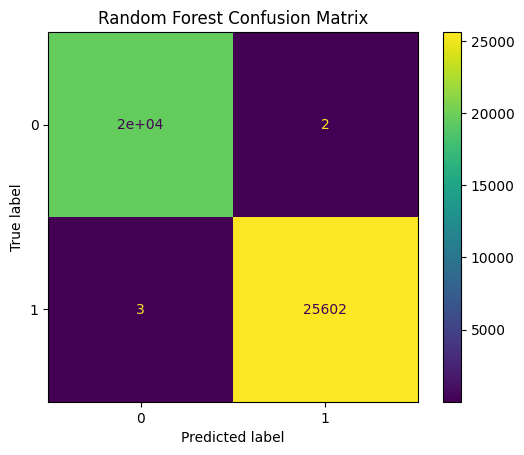

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:15:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Accuracy: 0.9999335445140997


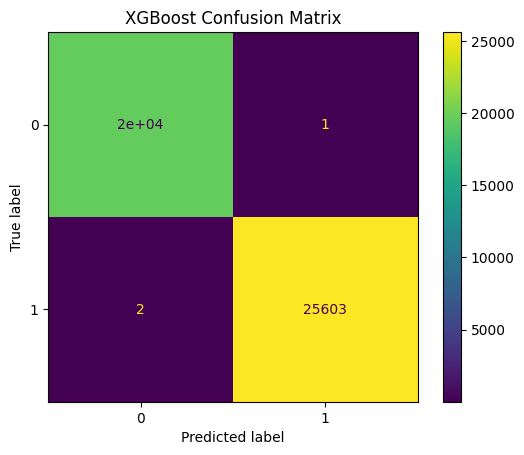

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:16:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Tuned XGBoost Accuracy: 0.9999113926854661


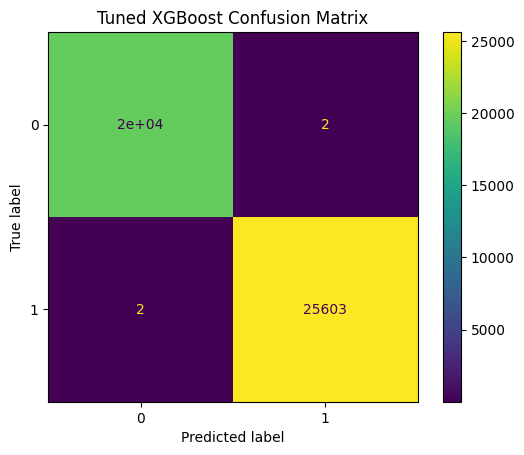

ROC-AUC Score: 0.9999097628165117


In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay

# Step 2: Load and clean data
df = pd.read_csv("DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()  # Clean column names
df = df.dropna()  # Drop missing values

# Step 3: Encode target
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])  # BENIGN=0, DDoS=1

# Step 4: Split data
X = df.drop('Label', axis=1)
y = df['Label']
scaler = StandardScaler()
# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN values
X.dropna(inplace=True)
# Update y to match the dropped rows
y = y[X.index]
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Step 5: Try Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 6: Evaluate Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Step 7: Try XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Step 8: Evaluate XGBoost
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost Confusion Matrix")
plt.show()

# Step 9: Hyperparameter Tuning for XGBoost (optional)
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.01]
}
grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
y_pred_best = grid.best_estimator_.predict(X_test)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

# Optional: ROC-AUC Score
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_best))